### Setup

In [ ]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML
from thinkstats import decorate

In [11]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

Downloaded 2002FemPreg.dct
Downloaded 2002FemPreg.dat.gz


In [12]:
dct_file = "2002FemPreg.dct"
dat_file = "2002FemPreg.dat.gz"

- El notebook usa una funcion definida por el auto para poder leer este tipo de datos

In [14]:
from statadict import parse_stata_dict


def read_stata(dct_file, dat_file):
    stata_dict = parse_stata_dict(dct_file)
    resp = pd.read_fwf(
        dat_file,
        names=stata_dict.names,
        colspecs=stata_dict.colspecs,
        compression="gzip",
    )
    return resp

### Primeras Vistas

In [15]:
preg = read_stata(dct_file, dat_file)

El resultado es un DataFrame, que es una estructura de datos de Pandas que representa datos tabulares en filas y columnas. Este DataFrame contiene una fila por cada embarazo reportado por una persona encuestada y una columna por cada variable. Una variable puede contener respuestas a una pregunta de la encuesta o valores calculados a partir de las respuestas a una o más preguntas.

Además de los datos, un DataFrame también contiene los nombres de las variables y sus tipos, y ofrece métodos para acceder y modificar los datos. El DataFrame tiene un atributo llamado shape que contiene el número de filas y columnas (filas, columnas):

In [16]:
preg.shape

(13593, 243)

In [17]:
# El metodo head proporciona los (x) primero elementos, x por default es 5
preg.head()

,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,poverty_i,laborfor_i,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw
0,1,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
1,1,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,3410.389399,3869.349602,6448.271112,2,9,1231
2,2,1,NaN,NaN,NaN,NaN,5.0,NaN,3.0,5.0,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
3,2,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231
4,2,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,0,7226.301740,8567.549110,12999.542264,2,12,1231


La columna izquierda es el índice del DataFrame, que contiene una etiqueta para cada fila. En este caso, las etiquetas son enteros que empiezan en 0, pero también pueden ser cadenas y otros tipos.

El DataFrame tiene un atributo llamado columns que contiene los nombres de las variables:

In [18]:
preg.columns

Index(['caseid', 'pregordr', 'howpreg_n', 'howpreg_p', 'moscurrp', 'nowprgdk',
       'pregend1', 'pregend2', 'nbrnaliv', 'multbrth',
       ...
       'poverty_i', 'laborfor_i', 'religion_i', 'metro_i', 'basewgt',
       'adj_mod_basewgt', 'finalwgt', 'secu_p', 'sest', 'cmintvw'],
      dtype='object', length=243)

In [19]:
pregordr = preg["pregordr"]

In [20]:
type(pregordr)

pandas.core.series.Series

Una columna del dataframe separada se la conoce como una serie, que representa una secuencia de valores

In [21]:
pregordr.head()

0    1
1    2
2    1
3    2
4    3
Name: pregordr, dtype: int64

Este dataset contiene 243 variables (columnas) de las cual se van a utilizar estas:
- caseid : ID del respondiente
- pregodr: Numero serial del embarazo. 1 - Primer embarazo, 2 - Segundo embarazo, y asi.
- prglngth: Duracion del embarazo en semanas
- outcome: Entero que representa la salida del embarazo. 1 representa nacimiento con vida
- birthord: Un número de serie para nacimientos vivos: el código para el primer hijo de una persona encuestada es 1, y así sucesivamente. Para resultados distintos de nacimiento con vida, este campo queda en blanco.
- birthwgt_lb y birthwgt_oz: Contienen las partes en libras y onzas del peso al nacer del bebé.
- agepreg: La edad de la madre al final del embarazo.
- finalwgt: El peso estadístico asociado a la persona encuestada. Es un valor de coma flotante que indica a cuántas personas de la población de EE. UU. representa esta persona encuestada.

### Validacion

Cuando los datos se exportan de un entorno de software y se importan en otro, pueden introducirse errores. Y cuando te estás familiarizando con un nuevo conjunto de datos, podrías decodificar los datos de forma incorrecta o malinterpretar su significado. Si inviertes tiempo en validar los datos, puedes ahorrar tiempo después y evitar errores.

Una manera de validar los datos es calcular estadísticas básicas y compararlas con resultados publicados. Por ejemplo, el manual de códigos de la NSFG incluye tablas que resumen cada variable. Aquí está la tabla de outcome, que codifica el resultado de cada embarazo:

In [22]:
preg.outcome

0        1
1        1
2        1
3        1
4        1
        ..
13588    1
13589    2
13590    2
13591    1
13592    1
Name: outcome, Length: 13593, dtype: int64

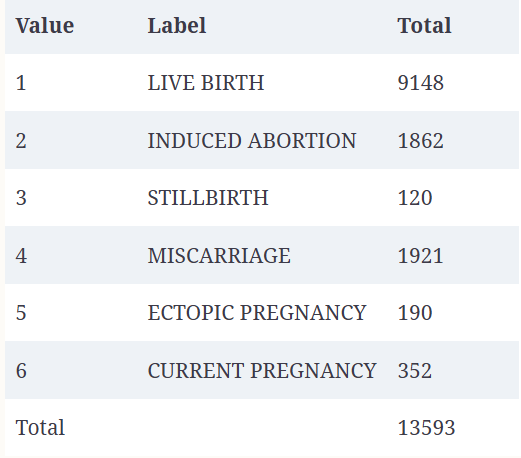

In [23]:
preg["outcome"].value_counts().sort_index()

outcome
1    9148
2    1862
3     120
4    1921
5     190
6     352
Name: count, dtype: int64

Lo mismo con otros campos como birthwgt_lb

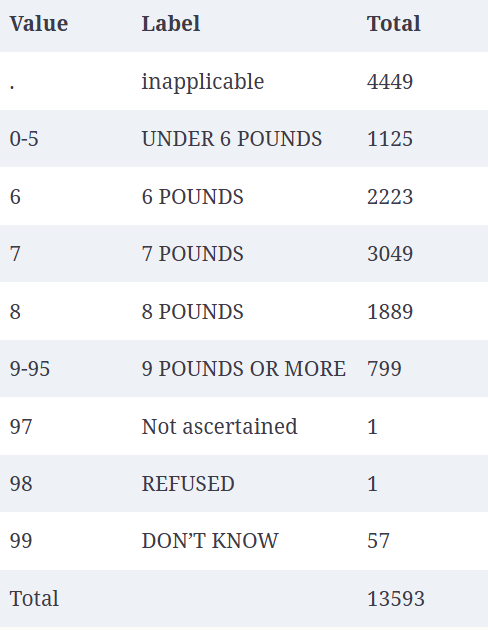

In [24]:
counts = preg["birthwgt_lb"].value_counts(dropna=False).sort_index()
counts

birthwgt_lb
0.0        8
1.0       40
2.0       53
3.0       98
4.0      229
5.0      697
6.0     2223
7.0     3049
8.0     1889
9.0      623
10.0     132
11.0      26
12.0      10
13.0       3
14.0       3
15.0       1
51.0       1
97.0       1
98.0       1
99.0      57
NaN     4449
Name: count, dtype: int64

In [26]:
# Para chequear el total de 0 - 5, tiene que dar 1125
counts.loc[0:5].sum()

np.int64(1125)

In [27]:
# Los valores 97, 98 y 99 representan casos donde el peso de nacimientos es desconocido, son valores centinelas, y por otra parte el 51 es raro
preg["birthwgt_lb"] = preg["birthwgt_lb"].replace([51, 97, 98, 99], np.nan)

### Transformacion

Otro proceso de data cleaning es convertir datos a diferentes formatos, y calcular otras operaciones

In [28]:
preg["agepreg"].mean()

np.float64(2468.8151197039497)

El valor agepreg calcula la edad de la madre al final del embarazo, pero está en centenarios, para pasarlo a ños lo podemos dividir por 100

In [29]:
preg["agepreg"] /= 100.0
preg["agepreg"].mean()

np.float64(24.6881511970395)

Otro ejemplo es el peso en lb y oz. Capaz es mejor ponerlo en una sola columna que contenga libras

In [30]:
# Primero limpiamos el oz como hicimos con lb
preg["birthwgt_oz"] = preg["birthwgt_oz"].replace([97, 98, 99], np.nan)

In [31]:
preg["totalwgt_lb"] = preg["birthwgt_lb"] + preg["birthwgt_oz"] / 16.0
preg["totalwgt_lb"].mean()

np.float64(7.265628457623368)

### Estadistica Descriptiva

Una estadistica es un numero derivado de un conjunto de datos, normalmente con la intencion de cuantificar algun aspecto de este. Ejemplos pueden ser la media, varianza, desviacion estandar, etc.

In [32]:
# Las series de Pandas tienen un metodo count que devuelve el numero de registros no nulos
weights = preg["totalwgt_lb"]
n = weights.count()
n

np.int64(9038)

In [33]:
# Tambien propociona el metodo sum que devuelve la suma de todos los valores, lo cual podemos usar para calcular la media
mean = weights.sum() / n
mean

np.float64(7.265628457623368)

In [34]:
# Cosa que se hace mas facil con el metodo mean
weights.mean()

np.float64(7.265628457623368)

La varianza es una estadística que cuantifica la dispersión de un conjunto de valores. Es la media de los cuadrados de las desviaciones, que son las distancias de cada punto con respecto a la media:

In [35]:
squared_deviations = (weights - mean) ** 2

In [ ]:
# Computamos la varianza asi
var = squared_deviations.sum() / n
var

In [37]:
# Como de esperar, la Series de pandas tiene un metodo para esto llamado var, pero ojo, es CASI lo mismo
weights.var()

np.float64(1.9832904288326545)

El resultado es ligeramente diferente porque cuando el método var calcula la media de las desviaciones al cuadrado, divide por n−1 en lugar de n. Esto se debe a que hay dos maneras de calcular la varianza de una muestra, según lo que estés tratando de hacer. El auto lo explicará mas adelante, pero en la práctica por lo general no importa. Si preferís la versión con n en el denominador, podés obtenerla pasando ddof=0 como argumento con nombre al método var:

In [38]:
weights.var(ddof=0)

np.float64(1.983070989750022)

En este conjunto de datos, la varianza de los pesos al nacer es de aproximadamente 1,98, pero ese valor es difícil de interpretar, entre otras cosas, está en unidades de libras al cuadrado. La varianza es útil en algunos cálculos, pero no es una buena manera de describir un conjunto de datos. Una mejor opción es la desviación estándar, que es la raíz cuadrada de la varianza. Podemos calcularla así:

In [39]:
std = np.sqrt(var)
std

np.float64(1.40821553384062)

In [40]:
# O de esta forma mas facil
weights.std(ddof=0)

np.float64(1.40821553384062)

En este conjunto de datos, la desviación estándar de los pesos al nacer es de aproximadamente 1,4 libras. De manera informal, los valores que están a una o dos desviaciones estándar de la media son comunes; los valores más alejados de la media son raros.

### Interpretacion

Para trabajar con datos de manera eficaz, tenés que pensar en dos niveles al mismo tiempo: el nivel de la estadística y el nivel del contexto. Como ejemplo, seleccionemos las filas en el archivo de embarazos con caseid 10229. El método query acepta una cadena que puede contener nombres de columnas, operadores de comparación y números, entre otras cosas:

In [41]:
subset = preg.query("caseid == 10229")
subset.shape

(7, 244)

Esto nos dice que el correspondiente 10229 (la persona embarazada con ese identificador) reportó 7 embarazos, veamos los outcomes, que estan en orden cronologico

In [42]:
subset["outcome"].values

array([4, 4, 4, 4, 4, 4, 1])

El código de resultado 1 indica un nacimiento con vida. El código 4 indica un aborto espontáneo. Es decir, una pérdida de embarazo, por lo general sin causa médica conocida.

Desde el punto de vista estadístico, esta persona encuestada no es inusual. La pérdida de embarazo es común y hay otras personas que reportaron tantas instancias. Pero, recordando el contexto, estos datos cuentan la historia de una mujer que estuvo embarazada seis veces, cada una terminando en aborto espontáneo. Su séptimo y más reciente embarazo terminó en un nacimiento con vida. Si consideramos estos datos con empatía, es natural sentirse conmovido por la historia que cuentan.

Cada fila en el conjunto de datos de la NSFG representa a una persona que brindó respuestas honestas a muchas preguntas personales y difíciles. Podemos usar estos datos para responder preguntas estadísticas sobre la vida familiar, la reproducción y la salud. Al mismo tiempo, tenemos la obligación de considerar a las personas representadas por los datos y brindarles respeto y gratitud.

### Glosario

- **evidencia anecdótica**: Datos recopilados de manera informal a partir de un pequeño número de casos individuales, a menudo sin muestreo sistemático.
- **estudio transversal**: Un estudio que recopila datos de una muestra representativa de una población en un único momento o intervalo de tiempo.
- **ciclo**: Un intervalo de recolección de datos en un estudio que recoge datos en múltiples intervalos temporales.
- **población**: El conjunto total de individuos u objetos que es objeto de un estudio.
- **muestra**: Un subconjunto de una población, a menudo seleccionado al azar.
- **personas encuestadas**: Personas que participan en una encuesta y responden preguntas.
- **representativa**: Una muestra es representativa si es similar a la población en aspectos que son importantes para los fines del estudio.
- **estratificada**: Una muestra es estratificada si sobrerrepresenta deliberadamente a algunos grupos, por lo general para asegurarse de que haya suficientes miembros para respaldar conclusiones válidas.
- **sobremuestreado**: Un grupo está sobremuestreado si sus miembros tienen una mayor probabilidad de aparecer en una muestra.
- **variable**: En datos de encuestas, una variable es un conjunto de respuestas a preguntas o valores calculados a partir de respuestas.
- **manual de códigos**: Documento que describe las variables de un conjunto de datos y proporciona otra información sobre los datos.
- **recodificación**: Variable que se calcula en función de otras variables de un conjunto de datos.
- **datos sin procesar**: Datos que no han sido procesados después de su recolección.
- **limpieza de datos**: Proceso para identificar y corregir errores en un conjunto de datos, tratar valores faltantes y calcular recodificaciones.
- **estadística**: Valor que describe o resume una propiedad de una muestra.
- **desviación estándar**: Estadístico que cuantifica la dispersión de los datos alrededor de la media.


### Ejercicios